# AlexNet Inspired Model

Sequential Model 1 was unable to effectively capture the global patterns present in the dataset. In this section, we propose a different architecture, largely inspired by the work on AlexNet, which achieved state-of-the-art performance in the ImageNet Large Scale Visual Recognition Challenge 2012.

Although AlexNet is now considered an older architecture, it remains a strong baseline for experimentation due to its simplicity and proven ability to learn hierarchical feature representations from images. In this notebook, we develop a AlexNet inspired architecture to the WikiArt dataset, introducing task-specific modifications to improve performance on artist classification.

In the paper, Krizhevsky et al. (2012) propose a deep convolutional neural network consisting of five convolutional layers, some followed by max-pooling layers, and three fully connected layers, with a final 1000-way softmax output layer. As mentioned previously, this model architecture was originally designed for the ImageNet dataset, which consists of approximately 15 million high-resolution images. The sheer size of this dataset makes efficiency a major concern. In our case, however, we work with a relatively smaller dataset; therefore, although computational efficiency remains important, it is not a primary concern with modernized implementations based on breakthorughs documented in the original AlexNet paper.

In [1]:
import keras

In [2]:
import tensorflow as tf

In [ ]:
# imports and constants
import os 
import glob
import keras
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import Image, display
import numpy as np

# Model building imports
from keras import Sequential, Input
from keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomBrightness, RandomContrast, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandAugment, RandomErasing, BatchNormalization, Activation, GlobalAveragePooling2D
from keras import callbacks, optimizers, losses
from keras.utils import image_dataset_from_directory
from keras import layers, models
from keras.preprocessing.image import load_img, img_to_array
import random 
from sklearn.utils.class_weight import compute_class_weight

split_dir = os.path.join("..", "dataset_split")
image_size = (128, 128)
batch_size = 32 # for lower GPU/CPU usage (but it as a lower training speed)
input_shape = (128, 128, 3)
seed = 42
epochs = 64

In [4]:
%run -i ../utils/evaluation_report.py
%run -i ../utils/loss_and_accuracy_plots.py
%run -i ../utils/grad_cam.py

## Load Data

In [5]:
# loading datasets (same as Pedro's)

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "train"),
    image_size = image_size,
    batch_size = batch_size,
    label_mode = "int", 
    # The labels are foing to be integers (0, 1, 2, ....) 
    # -> we are going to use the sparse_categorical_crossentropy loss in the label enconding part
    shuffle = True, # only on the train dataset
    seed = seed # reproducible
)

val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    image_size = image_size,
    batch_size = batch_size,
    label_mode = "int", 
    shuffle = False 
)

test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    image_size = image_size,
    batch_size = batch_size,
    label_mode = "int", 
    shuffle = False
)

# check to see if the loading is correct
num_classes = len(train_ds.class_names)
class_names = train_ds.class_names
print(f"Classes ({num_classes}): {class_names}")


Found 9338 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [6]:
num_classes = 23
train_labels = np.concatenate([labels for _, labels in train_ds], axis=0)

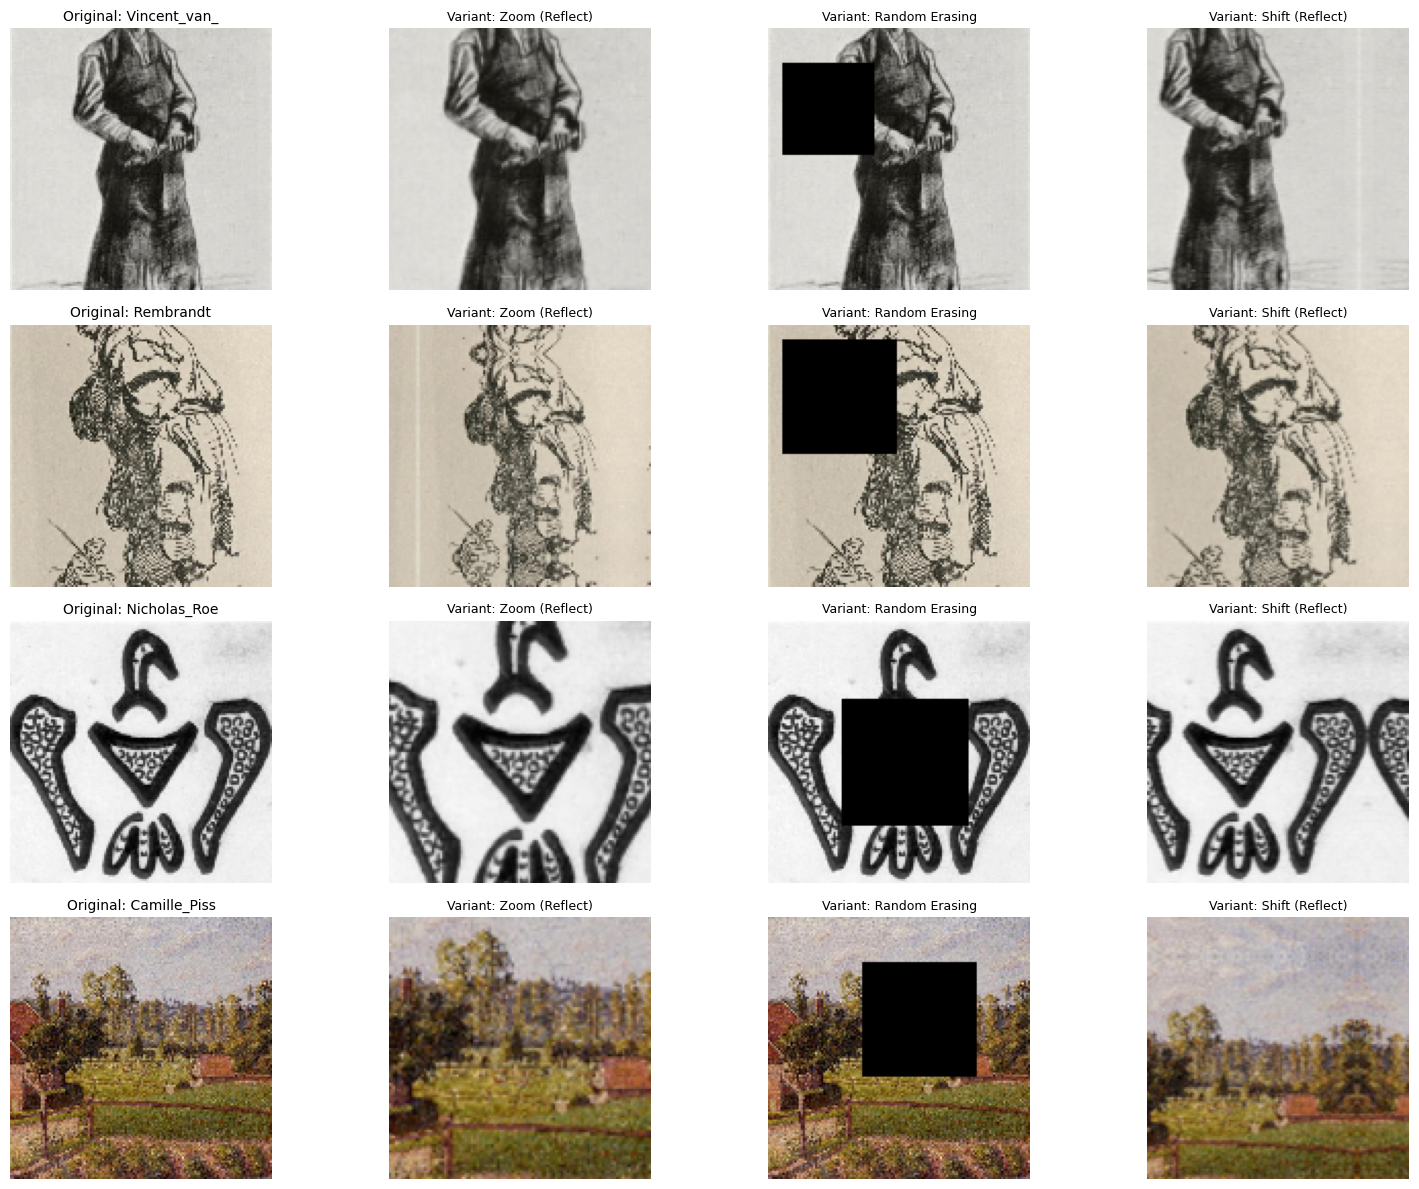

In [ ]:
# These functions plot a preview of augmentations performed on training set.


artists = ["Vincent_van_Gogh", "Rembrandt", "Nicholas_Roerich", "Camille_Pissarro"]
train_splited_dir = "../dataset_split/train"
img_size = (128, 128)

def manual_random_erasing(img_tensor, scale=(0.1, 0.25)):
    """Simulates KerasCV RandomErasing using pure TensorFlow"""
    img = img_tensor[0] # Work with single image from batch
    height, width, _ = img.shape
    
    # Calculate random area to erase
    area = height * width
    erase_area = np.random.uniform(scale[0], scale[1]) * area
    erase_h = int(np.sqrt(erase_area))
    erase_w = int(np.sqrt(erase_area))
    
    # Random location
    top = np.random.randint(0, height - erase_h)
    left = np.random.randint(0, width - erase_w)
    
    # Create mask (1s everywhere, 0s where we want to erase)
    mask = np.ones((height, width, 3), dtype=np.float32)
    mask[top:top+erase_h, left:left+erase_w, :] = 0.0
    
    return tf.multiply(img, mask)


fig, axes = plt.subplots(len(artists), 4, figsize=(16, 12))

for i, artist in enumerate(artists):
    artist_dir = os.path.join(train_splited_dir, artist)

    # Ensure directory exists and has files
    if not os.path.exists(artist_dir): continue
    img_list = os.listdir(artist_dir)
    if not img_list: continue
    
    img_path = os.path.join(artist_dir, img_list[0])
    
    # Load and prep
    img = img_to_array(load_img(img_path, target_size=img_size)) / 255.0
    img_batch = tf.expand_dims(img, 0)

    # Column 1: Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original: {artist[:12]}", fontsize=10)
    
    # Column 2: Zoom (Reflect)
    zoom_layer = tf.keras.layers.RandomZoom(-0.3, fill_mode='reflect')
    zoomed = zoom_layer(img_batch, training=True)[0]
    axes[i, 1].imshow(zoomed)
    axes[i, 1].set_title("Variant: Zoom (Reflect)", fontsize=9)
    
    # Column 3: Random Erasing (Manual TF version)
    erased = manual_random_erasing(img_batch)
    axes[i, 2].imshow(erased)
    axes[i, 2].set_title("Variant: Random Erasing", fontsize=9)
    
    # Column 4: Shift (Reflect)
    shift_layer = tf.keras.layers.RandomTranslation(0.2, 0.2, fill_mode='reflect')
    shifted = shift_layer(img_batch, training=True)[0]
    axes[i, 3].imshow(shifted)
    axes[i, 3].set_title("Variant: Shift (Reflect)", fontsize=9)

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

Description - From left to right: the original input image followed by three stochastic transformations: Zoom (Reflect), Random Erasing, and Shift (Reflect)

In order to combat overfitting , a data augmentation pipeline was implemented, as illustrated in figure above. Beyond standard spatial shifts and zooms, Random Erasing was utilized to force the network to focus on multiple descriptive regions of a painting rather than relying on a single distinctive landmark. All transformations utilized reflection padding to maintain the aesthetic continuity of the borders, ensuring that no artificial 'zero-padding' artifacts were introduced into the feature extraction process. 



## AlexNet Inspired Model

The proposed architecture was built from scratch using a Sequential pipeline. The final design is the result of an iterative process where several configurations were evaluated against the WikiArt dataset.

Initially, larger receptive fields in the first convolutional layers (7×7 and 11×11 kernels) with varying strides were tested, mirroring the original AlexNet. However, these did not prove effective for this specific dataset and led to significant underfitting, likely because the artistic features in these 224-pixel images were too granular for such large kernels.

Furthermore, a configuration utilizing Batch Normalization without Dropout—combined with a lower learning rate and aggressive decay (as proposed by Ioffe & Szegedy, 2015)—was implemented. This setup failed to outperform the baseline, as the absence of Dropout led to a lack of sufficient regularization. And unexpectdly the use of BatchNormalization lead to spiky validation curves.

Finally, a more complex classification head was evaluated within a higher-capacity architecture. Two specific configurations were tested: one featuring a single 512-unit dense layer, and another utilizing a dual-layer stack of 256 and 128 units. While these 'dense heads' increased training accuracy to over 60%, the validation accuracy remained stagnant at approximately 40%.

Ultimately, the optimized architecture—selected for its balance of expressive capacity and regularization—is defined in the code implementation below. A more intuitive visualization of the network’s hierarchical structure, including the spatial dimensions and feature map depths of each layer, is provided in the figure below.

In [ ]:
def build_model(num_classes, optimizer):
    model = Sequential([
        Input(shape=input_shape),

        Rescaling(1/255), 

        RandomFlip(mode="horizontal", seed=seed),
        RandomZoom(height_factor=0.2, width_factor=0.2, fill_mode="reflect", interpolation="bilinear", seed=seed),
        RandomContrast(0.15),
        RandomErasing(factor=0.2, scale=(0.02, 0.25), value_range=(0, 1),   fill_value=0.0), 
        
        # --- Conv Block 1 ---
        Conv2D(32, (5, 5), strides=2, padding='same', activation='relu'),
        MaxPooling2D(pool_size=2, strides=2),

        # --- Conv Block 2 ---
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=2, strides=2),

        # --- Conv Block 3 & 4 ---
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        
        # --- Conv Block 5 ---
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=2, strides=2),

        # --- Classification Head ---
        GlobalAveragePooling2D(), 
        
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax'),

    ], name="alexnet_inspired"
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [ ]:
# Save the best model
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",  
        patience=15,        
        restore_best_weights=True 
    ),
    
    # 3. Save the best version
    keras.callbacks.ModelCheckpoint(
        filepath="../saved_models/alex_net_inspired.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


Initial experiments utilized a ReduceLROnPlateau scheduler with several reduction factors. While this approach yielded somewhat better results, the combination of a high initial learning rate and aggressive reductions—triggered by plateaus in validation accuracy and erratic convergence. This behavior suggested that the model was trapped in suboptimal local minima, ultimately exacerbating overfitting.

To achieve a more stable loss behaviour, a CosineDecay learning rate schedule was implemented. This provided a smoother, more consistent reduction in the learning rate throughout the 64-epoch cycle, maintaining training stability and narrowing the gap between training and validation accuracy

In [ ]:
# Cosine Decay
initial_learning_rate = 0.0005
total_steps = 292 * epochs 

# Create the scheduler
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    alpha=0.0 # The final learning rate will be 0
)

# Use the scheduler directly in the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

alexnet_inspired = build_model(num_classes=num_classes, optimizer=optimizer)

In [11]:
alexnet_trained_model = alexnet_inspired.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks_list)

Epoch 1/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 32s 100ms/step - accuracy: 0.1136 - loss: 3.0418 - val_accuracy: 0.1334 - val_loss: 2.9522
Epoch 2/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 33s 113ms/step - accuracy: 0.1497 - loss: 2.9026 - val_accuracy: 0.1724 - val_loss: 2.7641
Epoch 3/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - accuracy: 0.1836 - loss: 2.7727 - val_accuracy: 0.2169 - val_loss: 2.6608
Epoch 4/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.2090 - loss: 2.6899 - val_accuracy: 0.2314 - val_loss: 2.5824
Epoch 5/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.2221 - loss: 2.6209 - val_accuracy: 0.2484 - val_loss: 2.5191
Epoch 6/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.2471 - loss: 2.5362 - val_accuracy: 0.2824 - val_loss: 2.4446
Epoch 7/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.2611 - loss: 2.4724 - val_accuracy: 0.2954 - val_loss: 2.3282
Epoch 8/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.2805 - loss: 2.3819

In [12]:
%run -i ../utils/evaluation_report.py
%run -i ../utils/loss_and_accuracy_plots.py
%run -i ../utils/grad_cam.py

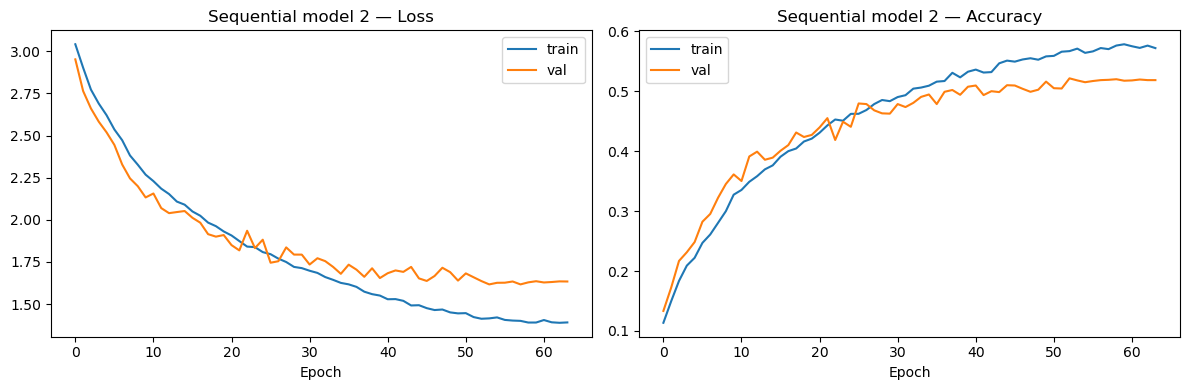

In [13]:
plot_history(alexnet_trained_model, "Sequential model 2")

--------- Classification report ---------
Top-1: 0.5107  Top-3: 0.7506  Top-5: 0.8491

                       precision    recall  f1-score   support

       Albrecht_Durer       0.72      0.61      0.66        87
      Boris_Kustodiev       0.29      0.14      0.19        66
     Camille_Pissarro       0.43      0.35      0.39        93
        Childe_Hassam       0.34      0.17      0.23        58
         Claude_Monet       0.51      0.61      0.56       140
          Edgar_Degas       0.18      0.06      0.09        64
        Eugene_Boudin       0.59      0.59      0.59        59
         Gustave_Dore       0.84      0.89      0.86        79
           Ilya_Repin       0.48      0.36      0.41        56
      Ivan_Aivazovsky       0.83      0.64      0.72        61
        Ivan_Shishkin       0.49      0.42      0.45        55
  John_Singer_Sargent       0.49      0.37      0.42        82
         Marc_Chagall       0.30      0.47      0.36        81
      Martiros_Saryan       0.

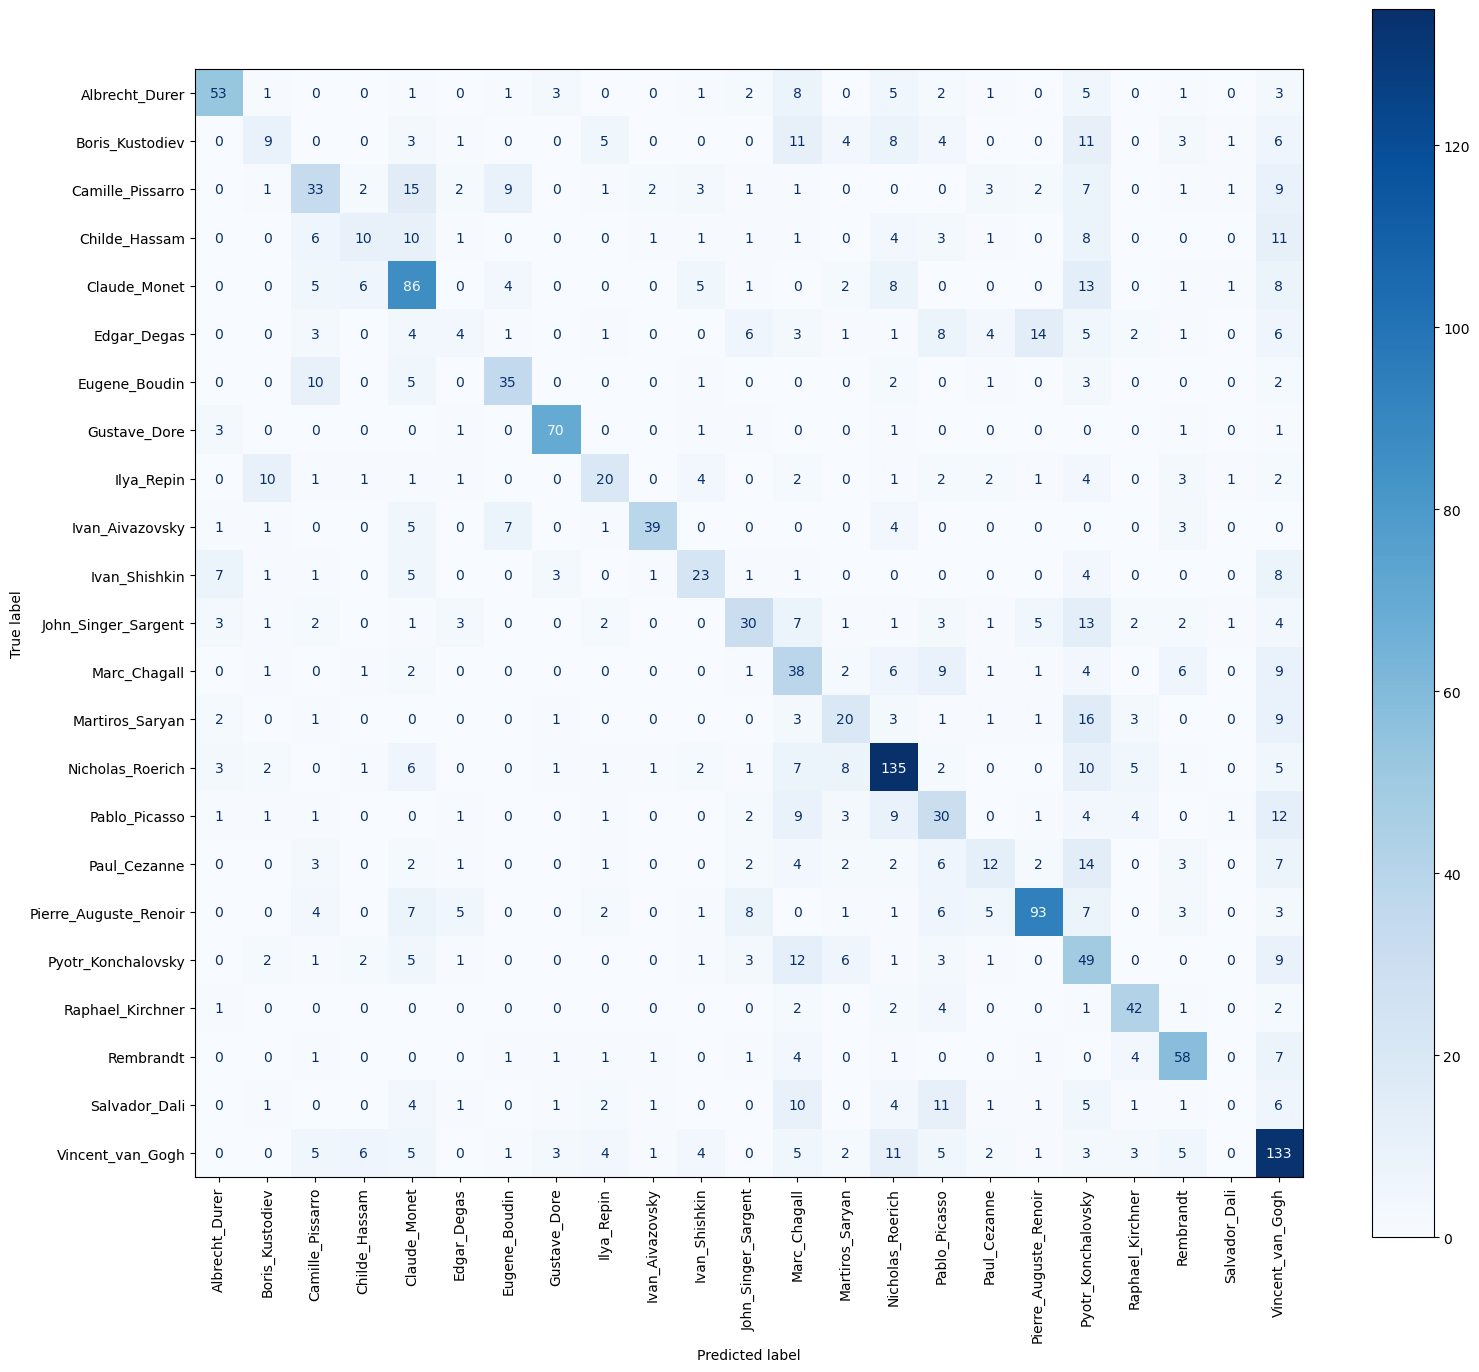

--------- Top 10 misclassifications ---------

                   True Artist  →  Predicted As                    Count
------------------------------------------------------------------------------------------
               Martiros_Saryan  →  Pyotr_Konchalovsky              16
              Camille_Pissarro  →  Claude_Monet                    15
                   Edgar_Degas  →  Pierre_Auguste_Renoir           14
                  Paul_Cezanne  →  Pyotr_Konchalovsky              14
                  Claude_Monet  →  Pyotr_Konchalovsky              13
           John_Singer_Sargent  →  Pyotr_Konchalovsky              13
                 Pablo_Picasso  →  Vincent_van_Gogh                12
            Pyotr_Konchalovsky  →  Marc_Chagall                    12
               Boris_Kustodiev  →  Marc_Chagall                    11
               Boris_Kustodiev  →  Pyotr_Konchalovsky              11


In [14]:
evaluate_model(alexnet_inspired, test_ds, class_names)

To address this, a weighted loss approach was implemented to penalize misclassifications of underrepresented artists more heavily. However, this proved ineffective in significantly shifting the validation accuracy, as the model continued to favor majority classes. This suggests that the bottleneck was not merely the gradient's 'importance,' but rather a combination of two factors:

    - Structural Limitations: The model’s shallow and lightweight architecture lacked the representational depth required to distinguish between artists with similar stylistic features.

    - Lack of Visual Variance: A fundamental lack of diversity in the minority samples meant the model simply did not see enough varied examples to generalize the minority styles effectively.



An alternative approach, undersampling the majority classes, was also considered. However, this was ultimately rejected; in a dataset of only 14,000 images, the loss of data involved in leveling the classes was deemed too costly, as it would have stripped the model of the high-quality feature extraction capabilities provided by the larger artist subsets."

## Weighted Model

In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))

In [16]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.0005,
        decay_steps=292 * epochs,
        alpha=0.0
    )
)

alexnet_weighted = build_model(num_classes=23, optimizer=optimizer)

alexnet_weighted.summary()

Model: "alexnet_inspired"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_1                │ (None, 128, 128, 3)    │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,447 (1.25 MB)

 Trainable params: 327,447 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_weighted = alexnet_weighted.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks_list,
    class_weight=class_weight_dict
)

Epoch 1/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.0731 - loss: 3.1030 - val_accuracy: 0.1089 - val_loss: 2.9887
Epoch 2/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.1124 - loss: 3.0088 - val_accuracy: 0.1194 - val_loss: 2.9350
Epoch 3/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.1162 - loss: 2.9752 - val_accuracy: 0.1494 - val_loss: 2.8774
Epoch 4/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.1392 - loss: 2.8999 - val_accuracy: 0.1744 - val_loss: 2.7568
Epoch 5/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.1566 - loss: 2.7916 - val_accuracy: 0.2099 - val_loss: 2.6566
Epoch 6/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.1780 - loss: 2.7125 - val_accuracy: 0.2154 - val_loss: 2.6514
Epoch 7/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.2018 - loss: 2.6395 - val_accuracy: 0.2544 - val_loss: 2.5119
Epoch 8/64
292/292 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - accuracy: 0.2170 - loss: 2.5737 - 

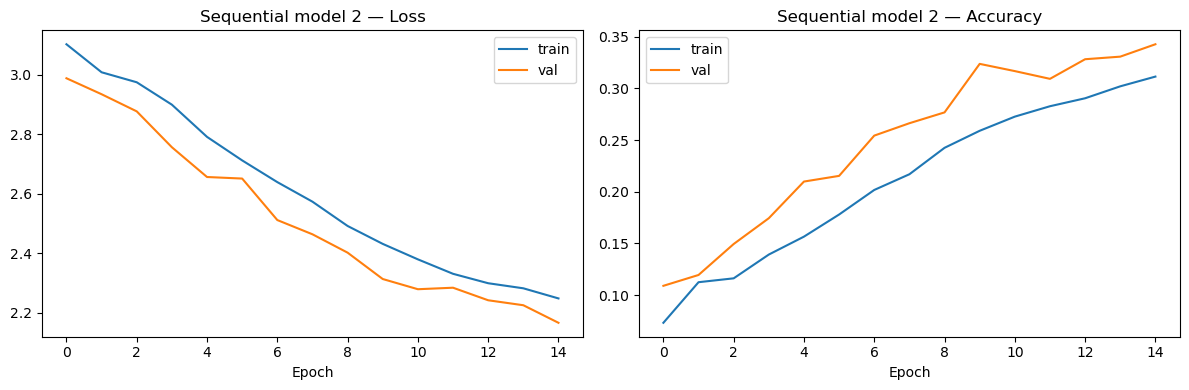

In [18]:
plot_history(history_weighted, "Sequential model 2")

--------- Classification report ---------
Top-1: 0.1059  Top-3: 0.2374  Top-5: 0.3498

                       precision    recall  f1-score   support

       Albrecht_Durer       0.00      0.00      0.00        87
      Boris_Kustodiev       0.00      0.00      0.00        66
     Camille_Pissarro       0.00      0.00      0.00        93
        Childe_Hassam       0.00      0.00      0.00        58
         Claude_Monet       0.00      0.00      0.00       140
          Edgar_Degas       0.00      0.00      0.00        64
        Eugene_Boudin       0.00      0.00      0.00        59
         Gustave_Dore       0.09      0.96      0.17        79
           Ilya_Repin       0.00      0.00      0.00        56
      Ivan_Aivazovsky       0.00      0.00      0.00        61
        Ivan_Shishkin       0.00      0.00      0.00        55
  John_Singer_Sargent       0.00      0.00      0.00        82
         Marc_Chagall       0.00      0.00      0.00        81
      Martiros_Saryan       0.

c:\Users\henri\AppData\Local\anaconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\henri\AppData\Local\anaconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\henri\AppData\Local\anaconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

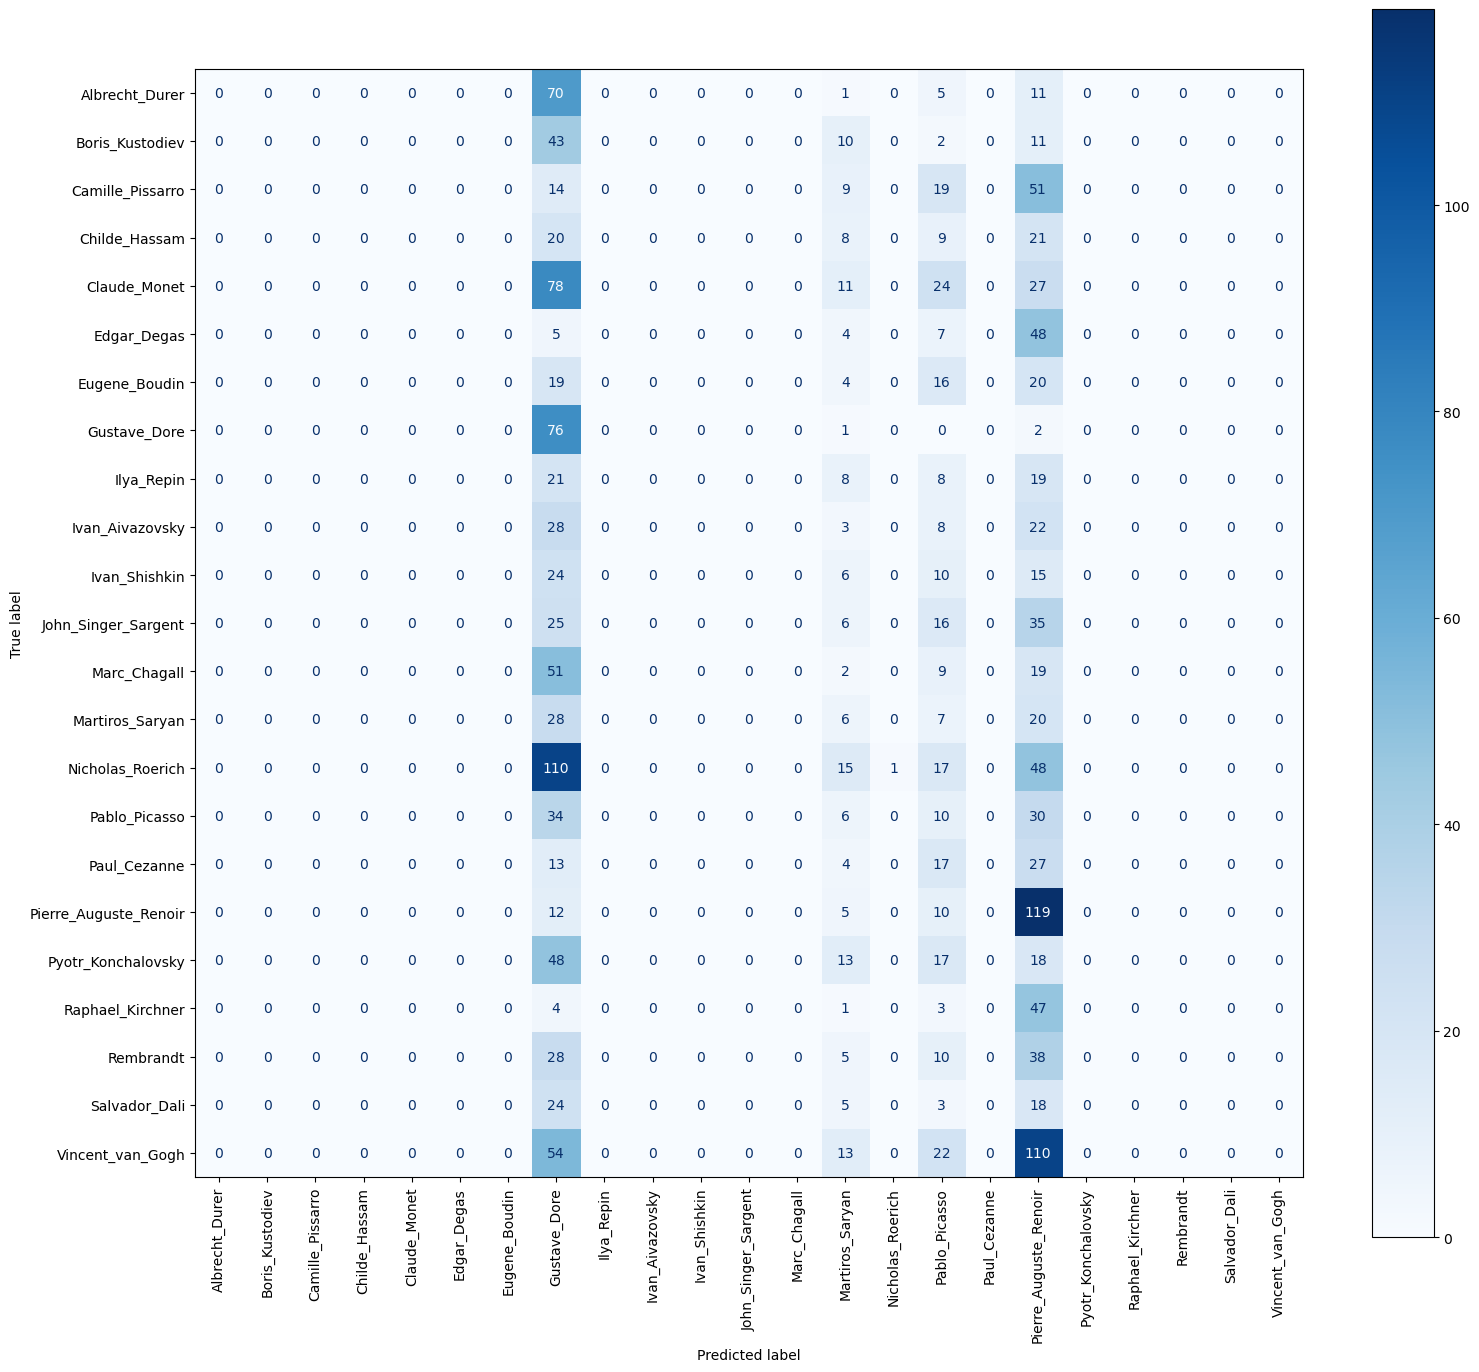

--------- Top 10 misclassifications ---------

                   True Artist  →  Predicted As                    Count
------------------------------------------------------------------------------------------
              Nicholas_Roerich  →  Gustave_Dore                    110
              Vincent_van_Gogh  →  Pierre_Auguste_Renoir           110
                  Claude_Monet  →  Gustave_Dore                    78
                Albrecht_Durer  →  Gustave_Dore                    70
              Vincent_van_Gogh  →  Gustave_Dore                    54
              Camille_Pissarro  →  Pierre_Auguste_Renoir           51
                  Marc_Chagall  →  Gustave_Dore                    51
                   Edgar_Degas  →  Pierre_Auguste_Renoir           48
              Nicholas_Roerich  →  Pierre_Auguste_Renoir           48
            Pyotr_Konchalovsky  →  Gustave_Dore                    48


In [19]:
evaluate_model(alexnet_weighted, test_ds, class_names)

## VG16

**Architecture Overview:**
Unlike the custom-built alexnet inspired model, VGG16  is a much depper convulutional neural network the architecture consists of 16 weight layers, characterized by its extreme simplicity: it uses exclusively 3×3 convolutional filters with a stride of 1, and 2×2 max-pooling layers.

For this project, VGG16 is utilized via Transfer Learning. The model is initialized with weights pre-trained on the ImageNet dataset, which contains over 1.4 million images across 1,000 classes.

**Motivation:**
The main goal in training a VGG16 model is to benchmark against the custom Sequential models. Because it was trained on a vast variety of real-world objects, it brings a "prior understanding" of visual geometry that can be fine-tuned to recognize the subtle nuances of fine art. Comparing VGG16 to Model B allows us to determine if the complex, deep features of a standard industry model outperform a specialized, leaner architecture in the context of high-variance artistic datasets.

In [22]:
epochs=10

In [23]:
# Load VGG16 Base 
base_model = tf.keras.applications.VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(128, 128, 3)
)

# Freeze the base 
base_model.trainable = False 

# Build the Architecture
vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(23, activation='softmax') 
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Train 
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=callbacks_list,
    class_weight=class_weight_dict
)

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 265s 903ms/step - accuracy: 0.1469 - loss: 4.6999 - val_accuracy: 0.2719 - val_loss: 2.5581
Epoch 2/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 265s 908ms/step - accuracy: 0.2532 - loss: 2.5786 - val_accuracy: 0.3568 - val_loss: 2.2421
Epoch 3/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 264s 905ms/step - accuracy: 0.3370 - loss: 2.2408 - val_accuracy: 0.3978 - val_loss: 2.0532
Epoch 4/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 265s 908ms/step - accuracy: 0.3816 - loss: 2.0353 - val_accuracy: 0.4458 - val_loss: 1.9282
Epoch 5/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 280s 959ms/step - accuracy: 0.4233 - loss: 1.8611 - val_accuracy: 0.4458 - val_loss: 1.8799
Epoch 6/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 273s 935ms/step - accuracy: 0.4659 - loss: 1.7247 - val_accuracy: 0.4668 - val_loss: 1.8242
Epoch 7/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.4875 - loss: 1.5883 - val_accuracy: 0.4818 - val_loss: 1.7559
Epoch 8/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.5229 - loss:

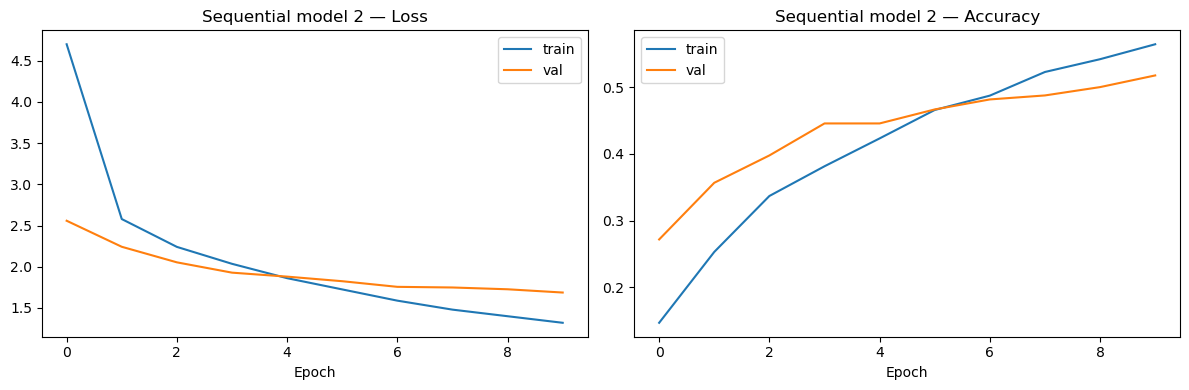

In [24]:
plot_history(history_vgg, "Sequential model 2")

--------- Classification report ---------
Top-1: 0.2664  Top-3: 0.4558  Top-5: 0.5827

                       precision    recall  f1-score   support

       Albrecht_Durer       0.27      0.25      0.26        87
      Boris_Kustodiev       0.16      0.14      0.15        66
     Camille_Pissarro       0.23      0.18      0.20        93
        Childe_Hassam       0.07      0.14      0.10        58
         Claude_Monet       0.26      0.23      0.24       140
          Edgar_Degas       0.19      0.17      0.18        64
        Eugene_Boudin       0.32      0.68      0.43        59
         Gustave_Dore       0.38      0.57      0.46        79
           Ilya_Repin       0.11      0.09      0.10        56
      Ivan_Aivazovsky       0.47      0.75      0.58        61
        Ivan_Shishkin       0.21      0.53      0.30        55
  John_Singer_Sargent       0.21      0.18      0.19        82
         Marc_Chagall       0.22      0.30      0.25        81
      Martiros_Saryan       0.

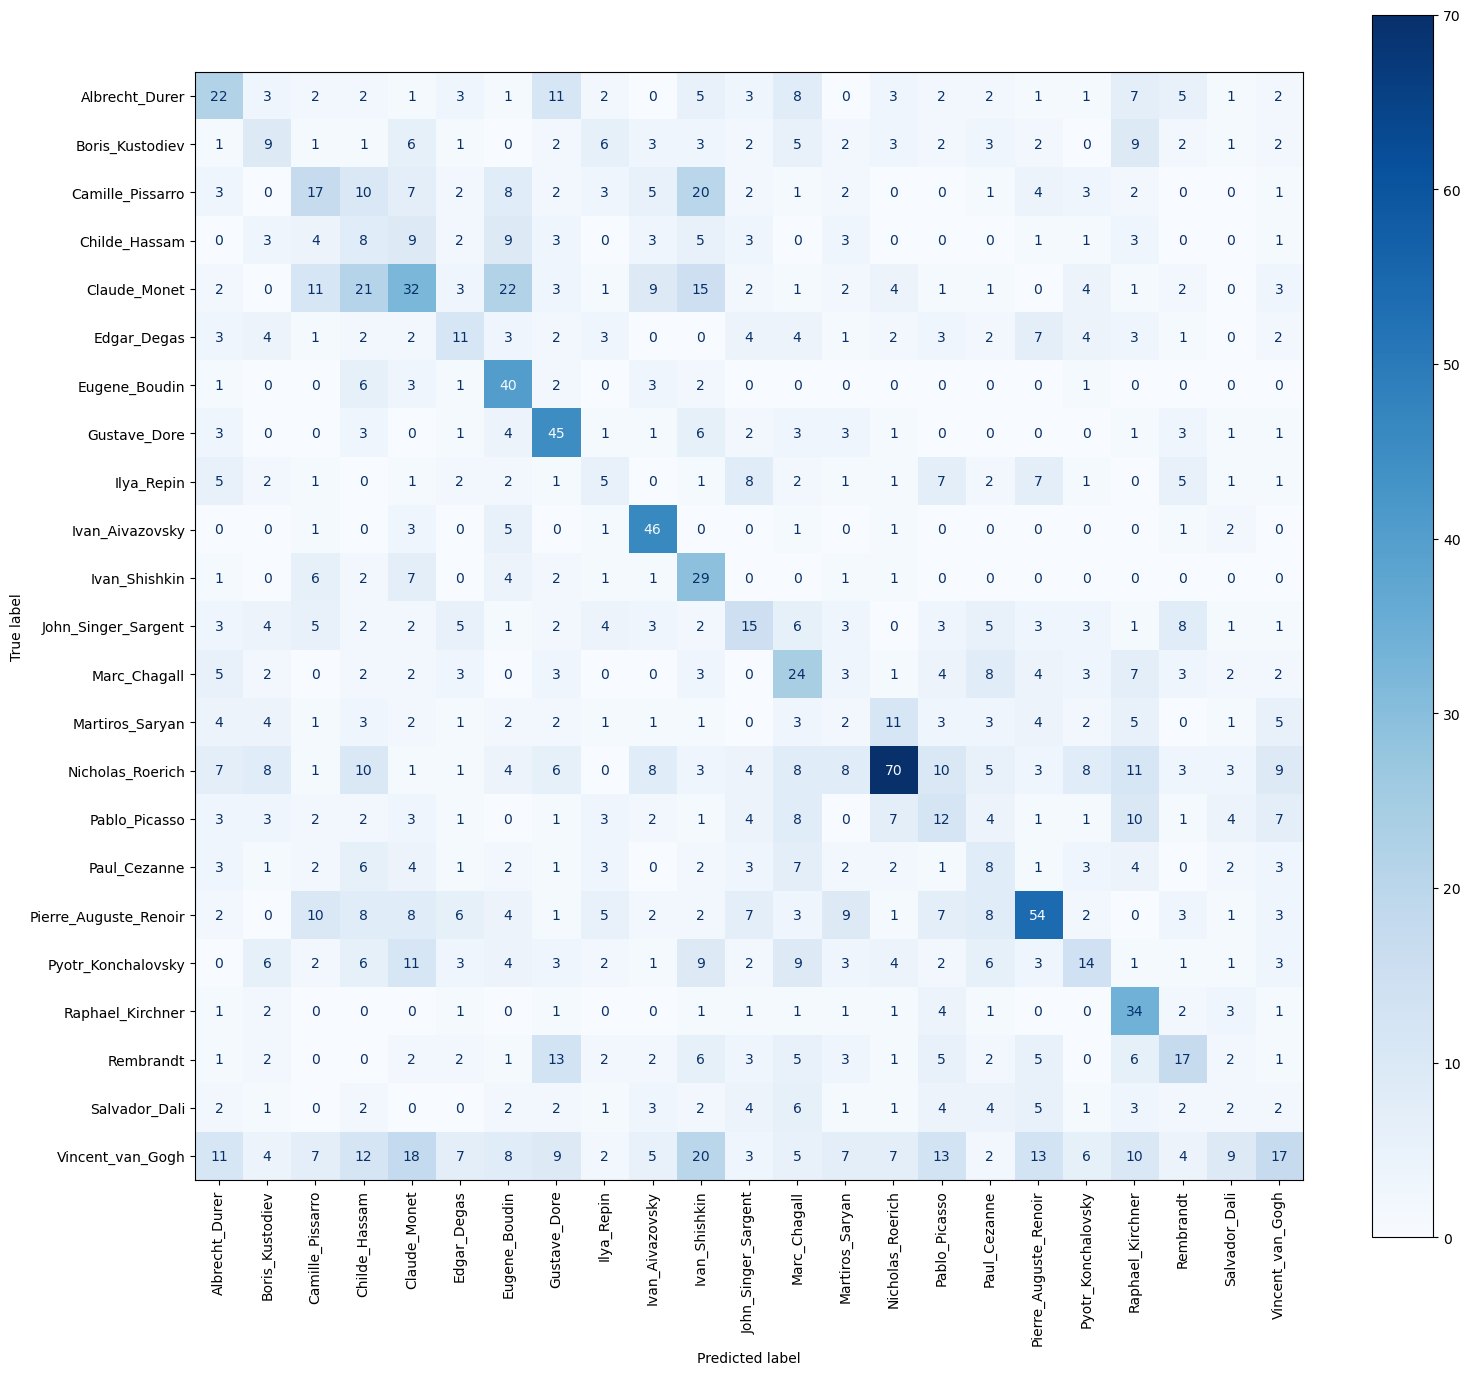

--------- Top 10 misclassifications ---------

                   True Artist  →  Predicted As                    Count
------------------------------------------------------------------------------------------
                  Claude_Monet  →  Eugene_Boudin                   22
                  Claude_Monet  →  Childe_Hassam                   21
              Camille_Pissarro  →  Ivan_Shishkin                   20
              Vincent_van_Gogh  →  Ivan_Shishkin                   20
              Vincent_van_Gogh  →  Claude_Monet                    18
                  Claude_Monet  →  Ivan_Shishkin                   15
                     Rembrandt  →  Gustave_Dore                    13
              Vincent_van_Gogh  →  Pablo_Picasso                   13
              Vincent_van_Gogh  →  Pierre_Auguste_Renoir           13
              Vincent_van_Gogh  →  Childe_Hassam                   12


In [25]:
evaluate_model(vgg_model, test_ds, class_names)

## GradCam

While performance metrics like accuracy and loss provide quantification of of Model performance, they do not explain why the model makes specific classification decisions. To address this "black box" problem, we implement Grad-CAM (Gradient-weighted Class Activation Mapping).

Grad-CAM uses the gradients of any target concept (in this case, the predicted artist) flowing into the final convolutional layer of the network. By analyzing these gradients, we can produce a coarse localization map highlighting the important regions in the image for predicting that concept.

In [ ]:
def get_image_path_by_artist(artist_name, dataset_path=train_splited_dir):
    # Look into the specific artist's folder
    artist_folder = os.path.join(dataset_path, artist_name)
    paths = glob.glob(os.path.join(artist_folder, "*.jpg"))
    
    if paths:
        return paths[0] # Returns the first painting found for that artist
    else:
        print("Artist folder not found!")
        return None

# Usage:
target_artist = class_names[0] # Get the name of your first artist
img_path = get_image_path_by_artist(target_artist)

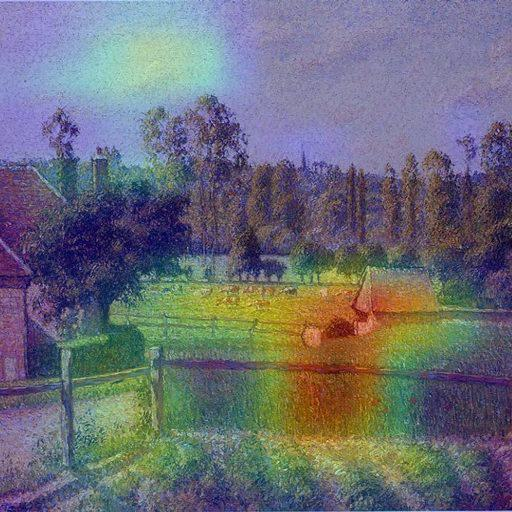

In [ ]:
def make_alexnet_heatmap_final(img_array, model, last_conv_name):
    # Since alexnet model was defined using Sequential pipeline grad_cam implementation is not very straightforward
    # 1. Manually apply the Rescaling 
    x = img_array / 255.0
    
    # 2. Extract layers for the Grad-CAM path
    # We skip layers 0-5 (Input, Rescaling, and the 4 Augmentation layers)
    # The first Conv2D is layer index 6
    img_input = tf.keras.Input(shape=(128, 128, 3))
    curr_x = img_input
    target_output = None
    
    # Find layers starting from the first Conv2D
    start_idx = 0
    for i, layer in enumerate(model.layers):
        if "conv2d" in layer.name:
            start_idx = i
            break
            
    for i in range(start_idx, len(model.layers)):
        layer = model.layers[i]
        curr_x = layer(curr_x)
        if layer.name == last_conv_name:
            target_output = curr_x

    grad_model = tf.keras.Model(inputs=img_input, outputs=[target_output, curr_x])

    # 3. Standard Gradient Tape
    with tf.GradientTape() as tape:
        # We pass the already-scaled 'x' here
        conv_out, preds = grad_model(x)
        top_class_channel = preds[:, tf.argmax(preds[0])]

    grads = tape.gradient(top_class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Create heatmap
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Relu + Normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()


#  last conv layer is named 'conv2d_4' 
last_conv = [l.name for l in alexnet_inspired.layers if "conv2d" in l.name][-1]
heatmap = make_alexnet_heatmap_final(img_array, alexnet_inspired, last_conv)
save_and_display_gradcam(img_path, heatmap)

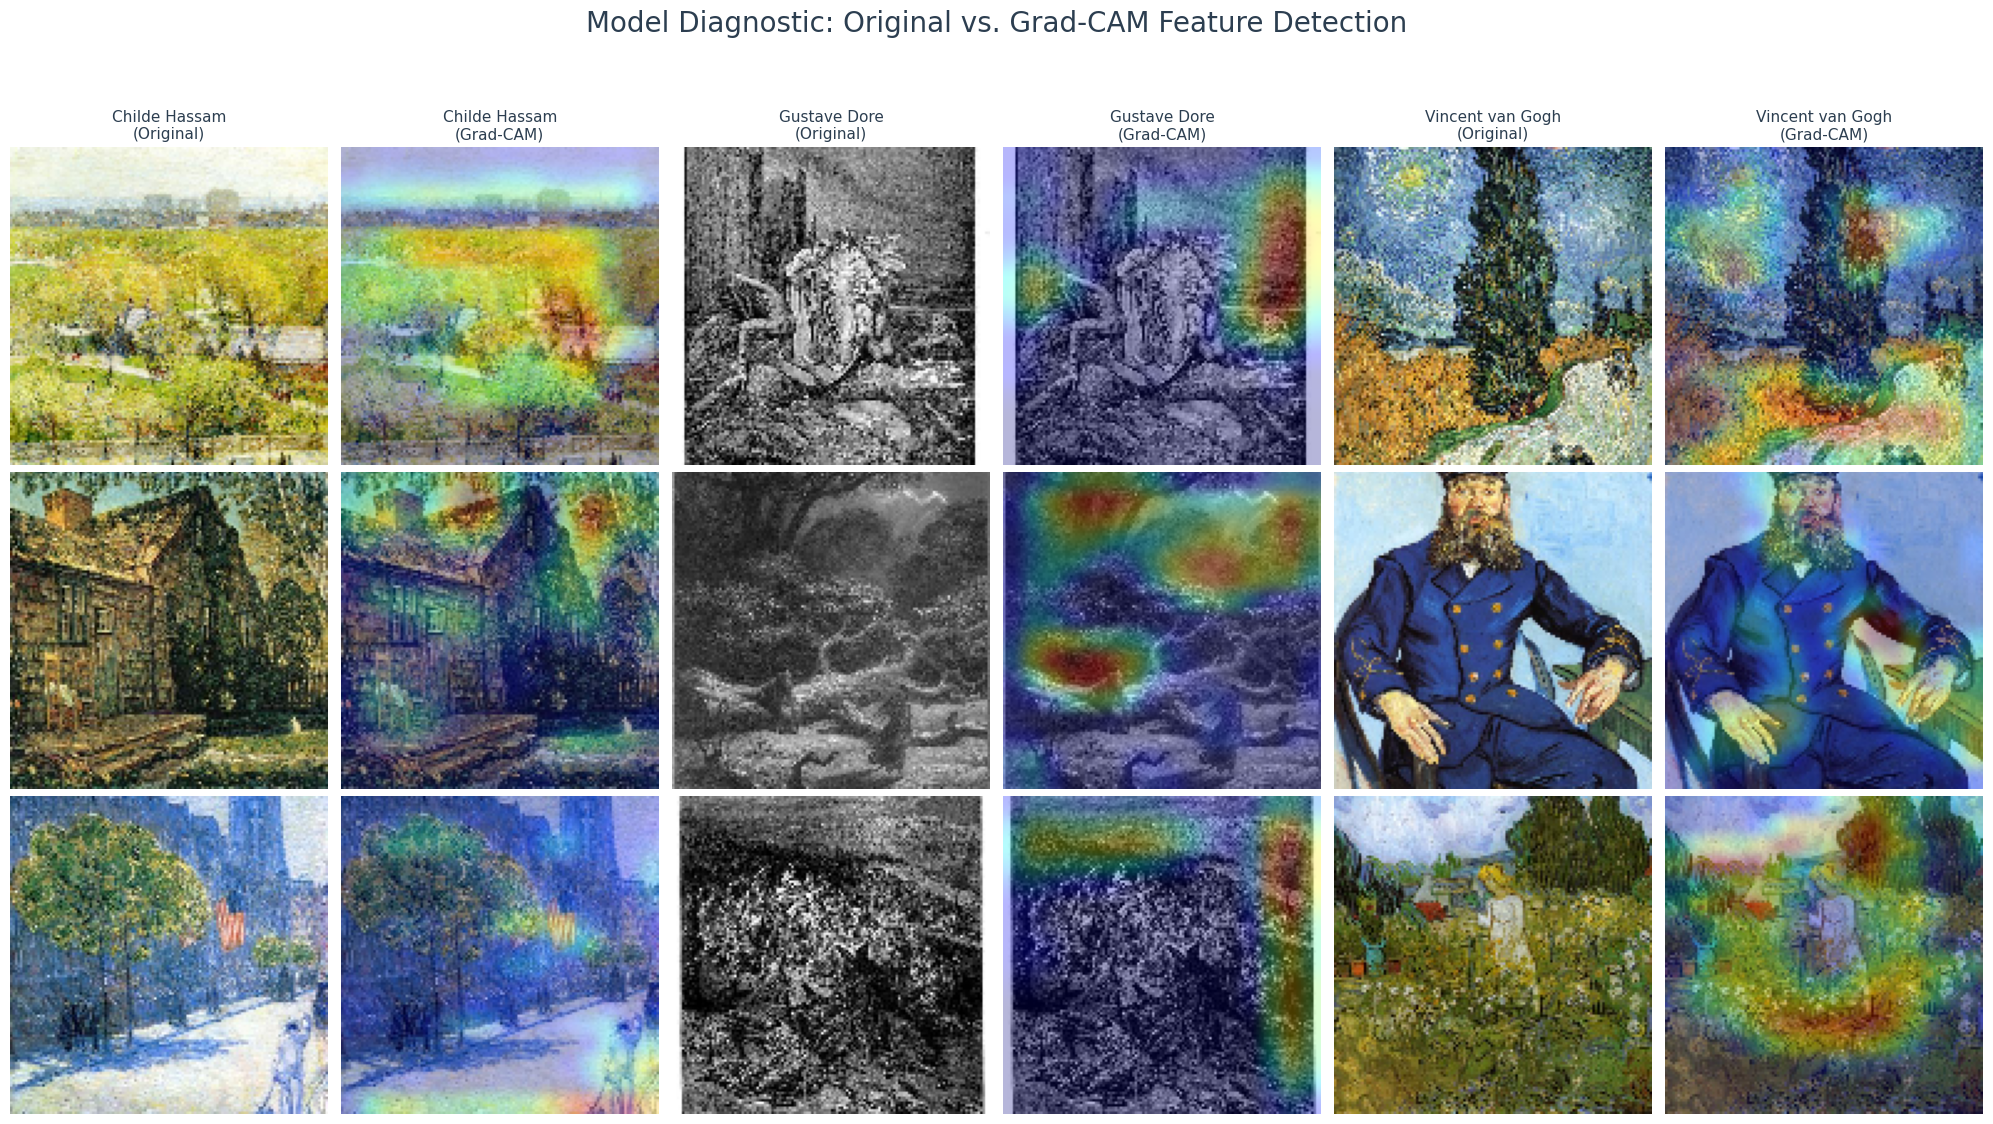

In [ ]:
from PIL import Image as PILImage

def plot_gradcam_diagnostic_comparison(model, dataset_path, class_names, last_conv_name):
    # Standard clean styling
    plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 9})
    
    # 3 rows (samples), 6 columns (3 Artists * 2 views each)
    fig, axes = plt.subplots(3, 6, figsize=(20, 12))
    fig.patch.set_facecolor('white')
    
    fig.suptitle("Model Diagnostic: Original vs. Grad-CAM Feature Detection", 
                 fontsize=20, y=0.98, color='#2c3e50')

    # Select 3 distinct artists
    selected_artists = random.sample(class_names, 3)

    for artist_idx, artist_name in enumerate(selected_artists):
        artist_folder = os.path.join(dataset_path, artist_name)
        all_images = os.listdir(artist_folder)
        img_names = random.sample(all_images, 3)

        # Calculate which columns belong to this artist
        # Artist 0 -> Col 0 (Orig) & 1 (CAM)
        # Artist 1 -> Col 2 (Orig) & 3 (CAM)
        # Artist 2 -> Col 4 (Orig) & 5 (CAM)
        col_orig = artist_idx * 2
        col_cam = col_orig + 1

        for row in range(3):
            img_path = os.path.join(artist_folder, img_names[row])

            # --- 1. Prepare Data ---
            img_array = get_img_array(img_path, size=(128, 128))
            heatmap = make_alexnet_heatmap_final(img_array, model, last_conv_name)

            # --- 2. Original Image ---
            img_original = keras.utils.load_img(img_path, target_size=(128, 128))
            axes[row, col_orig].imshow(img_original)
            axes[row, col_orig].axis("off")

            # --- 3. Grad-CAM Overlay ---
            img_original_arr = keras.utils.img_to_array(img_original)
            
            # Heatmap Processing
            heatmap_rescaled = np.uint8(255 * heatmap)
            jet = mpl.colormaps["jet"]
            jet_colors = jet(np.arange(256))[:, :3]
            jet_heatmap = jet_colors[heatmap_rescaled]
            
            # Smooth resizing (removes pixelation)
            jet_heatmap = keras.utils.array_to_img(jet_heatmap).resize((128, 128), resample=PILImage.BICUBIC)
            jet_heatmap = keras.utils.img_to_array(jet_heatmap)
            
            superimposed_img = jet_heatmap * 0.4 + img_original_arr
            superimposed_img = keras.utils.array_to_img(superimposed_img)
            
            axes[row, col_cam].imshow(superimposed_img)
            axes[row, col_cam].axis("off")

            # --- 4. Labels ---
            if row == 0:
                clean_name = artist_name.replace('_', ' ')
                # Center label over the two columns
                axes[row, col_orig].set_title(f"{clean_name}\n(Original)", fontsize=11, color='#2c3e50')
                axes[row, col_cam].set_title(f"{clean_name}\n(Grad-CAM)", fontsize=11, color='#2c3e50')

    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    plt.show()

# Execution call
last_conv_alex = [l.name for l in alexnet_inspired.layers if "conv2d" in l.name][-1]

plot_gradcam_diagnostic_comparison(
    model=alexnet_inspired, 
    dataset_path=train_splited_dir, 
    class_names=class_names, 
    last_conv_name=last_conv_alex
)